In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/content/superstore_raw (1).csv")

In [4]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  06-12-2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   consumer  United States        HENDERSON  ...   
1      Claire Gute   CONSUMER  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      LOS ANGELES  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
df["Category"] = df["Category"].str.title()


In [7]:
category_sales = df.groupby("Category")["Sales"].sum()

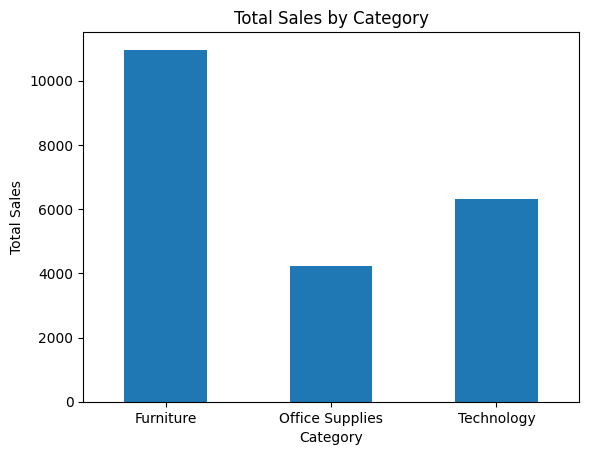

In [8]:
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

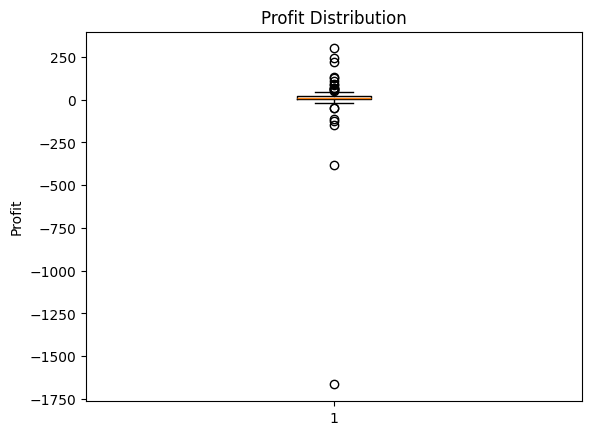

In [9]:
plt.boxplot(df["Profit"].dropna())
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.show()

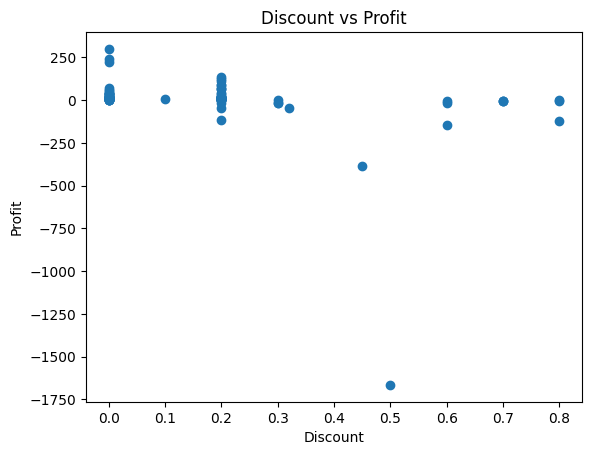

In [10]:
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [11]:
numerical_data = df.select_dtypes(include="number")

In [12]:
correlation_matrix = numerical_data.corr()


In [13]:
print(correlation_matrix)


               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000    -0.090782 -0.250134 -0.119111 -0.108007  0.068553
Postal Code -0.090782     1.000000 -0.016381  0.027921  0.080849  0.139706
Sales       -0.250134    -0.016381  1.000000  0.412793  0.122386 -0.542119
Quantity    -0.119111     0.027921  0.412793  1.000000  0.100989 -0.126887
Discount    -0.108007     0.080849  0.122386  0.100989  1.000000 -0.283765
Profit       0.068553     0.139706 -0.542119 -0.126887 -0.283765  1.000000


In [17]:
import seaborn as sns

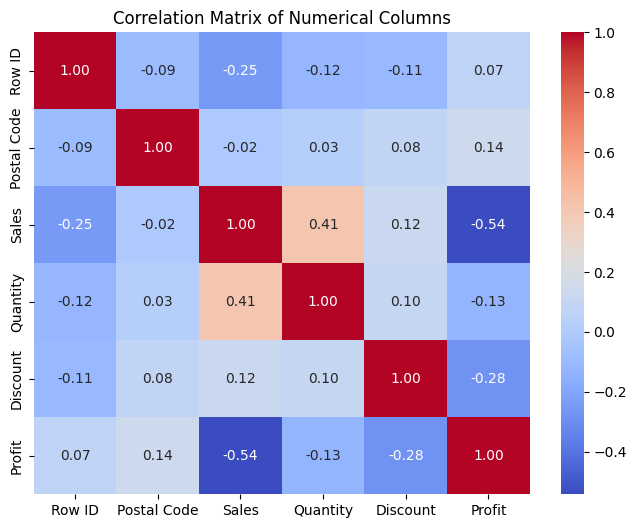

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Columns")
plt.show()

In [22]:
category_profit = df.groupby('Category')['Profit'].sum()

In [23]:
highest_profit_category = category_profit.idxmax()
highest_profit = category_profit.max()

In [24]:
print("Category with highest total profit:", highest_profit_category)
print("Total profit:", highest_profit)

Category with highest total profit: Technology
Total profit: 903.6039
